# Models + Raman Scattering corrections 

## This notebook is for developing the Raman-needed methods for models

## v1


In [6]:
from importlib import reload
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d

from ocpy.utils import plotting
from ocpy.hydrolight import loisel23

from bing.rt import raman
from bing.rt import rrs
from bing import rt as bing_rt
from bing.fitting import l23 as fit_l23
from bing.parameters import standard
from bing import plotting as bing_plot
from bing import evaluate as bing_eval

%matplotlib inline

# Fit first without Raman

In [7]:
idx = 170
p = standard.expb_pow(satellite='PACE', add_noise=True, variable_Gordon=False)#,
                     #nsteps=1000, nburn=100)  
chains, models, prep_dict, idx, extras = fit_l23.fit_one(p, idx)

idx=170
Running burn-in


100%|█████████████████████████████████████| 1000/1000 [00:02<00:00, 349.51it/s]


Running full model


100%|███████████████████████████████████| 40000/40000 [01:24<00:00, 471.27it/s]


## Show fit

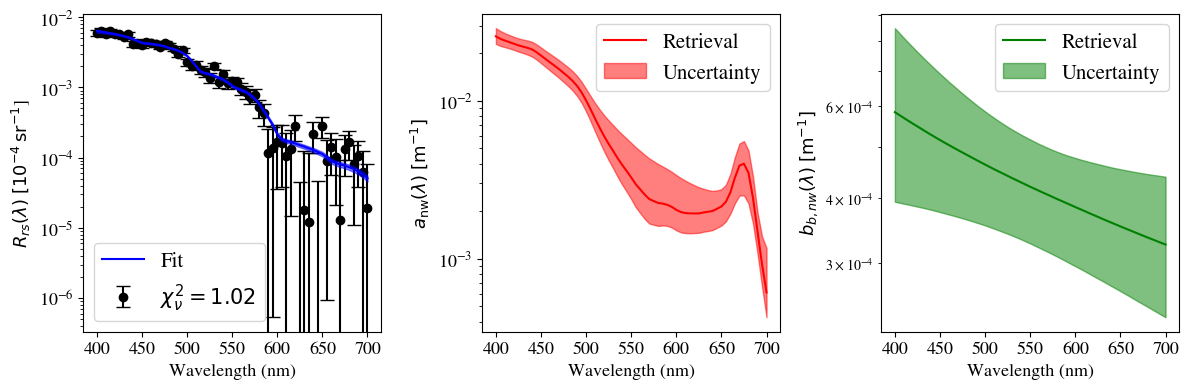

In [8]:
_ = bing_plot.show_fits(models, chains,  None, None,
                figsize=(12,4),
                fontsize=13.,
                show=True,
                Rrs_true=dict(wave=models[0].wave, spec=prep_dict['model_Rrs'], var=prep_dict['model_varRrs']),
                log_abb=True )

## Stats

In [9]:
stats = bing_eval.calc_stats(chains, names=models[0].pnames+models[1].pnames)
stats

{'names': ['Adg', 'Sdg', 'Aph', 'Bnw', 'beta'],
 'med': array([-1.7058729 ,  0.01493126, -1.9843673 , -3.416063  ,  1.0661073 ],
       dtype=float32),
 'p14': array([-1.7734617 ,  0.01138017, -2.159434  , -3.4883573 ,  0.3294948 ],
       dtype=float32),
 'p86': array([-1.6369135 ,  0.01856641, -1.878858  , -3.3524885 ,  1.7399147 ],
       dtype=float32)}

## Show IOPs at excitation wavelengths

### a

In [10]:
a_ex = models[0].eval_a_ex(stats['med'][:3])
a = models[0].eval_a(stats['med'][:3])
# non-water
#turn_off = np.array([0., 0., -3])
turn_off = np.array([0., 0., 0])
anw_ex = models[0].eval_anw(stats['med'][:3]+turn_off, wave=models[0].wave_ex)
anw = models[0].eval_anw(stats['med'][:3]+turn_off)

<Figure size 700x700 with 0 Axes>

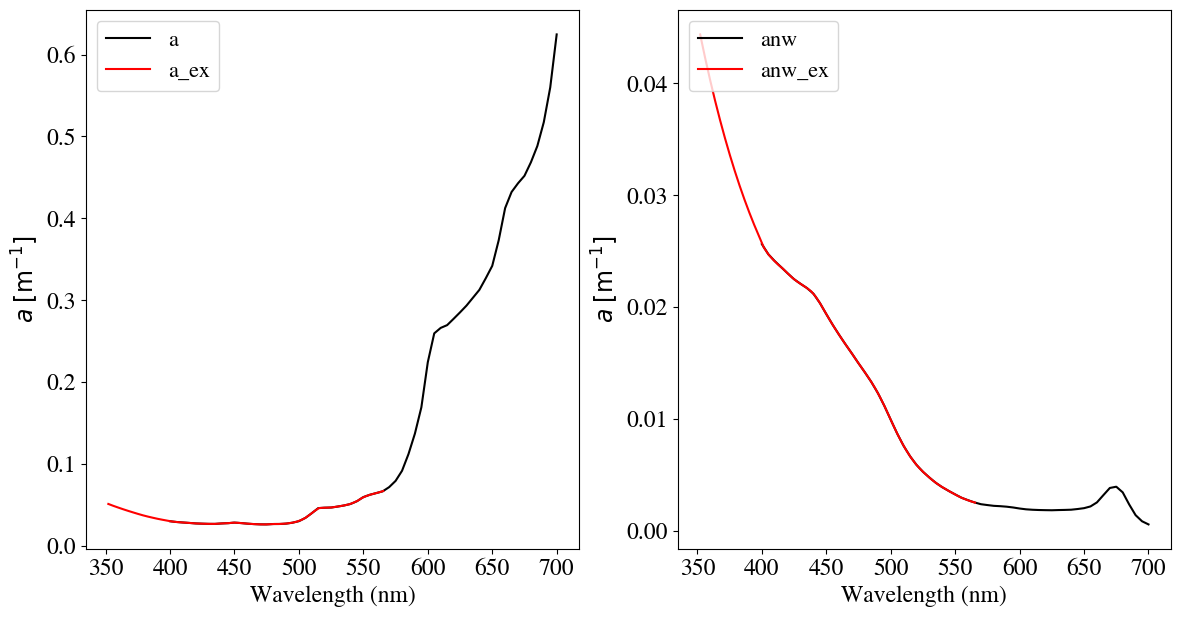

In [11]:
fig = plt.figure(figsize=(7,7))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
#
ax1.plot(models[0].wave, a.flatten(), label='a', color='black')
ax1.plot(models[0].wave_ex, a_ex.flatten(), label='a_ex', color='red')

ax2.plot(models[0].wave, anw.flatten(), label='anw', color='black')
ax2.plot(models[0].wave_ex, anw_ex.flatten(), label='anw_ex', color='red')
#
for ax in [ax1, ax2]:
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel(r'$a \; \rm [m^{-1}]$')
#ax.set_yscale('log')
#ax.set_ylim(1e-6, 1e-2)
    plotting.set_fontsize(ax, 17.)
    ax.legend(loc='upper left', fontsize=16.)
plt.show()

### bb

In [12]:
bb_ex = models[1].eval_bb_ex(stats['med'][3:])
bb = models[1].eval_bb(stats['med'][3:])
# non-water
bbnw_ex = models[1].eval_bbnw(stats['med'][3:], wave=models[1].wave_ex)
bbnw = models[1].eval_bbnw(stats['med'][3:])

<Figure size 700x700 with 0 Axes>

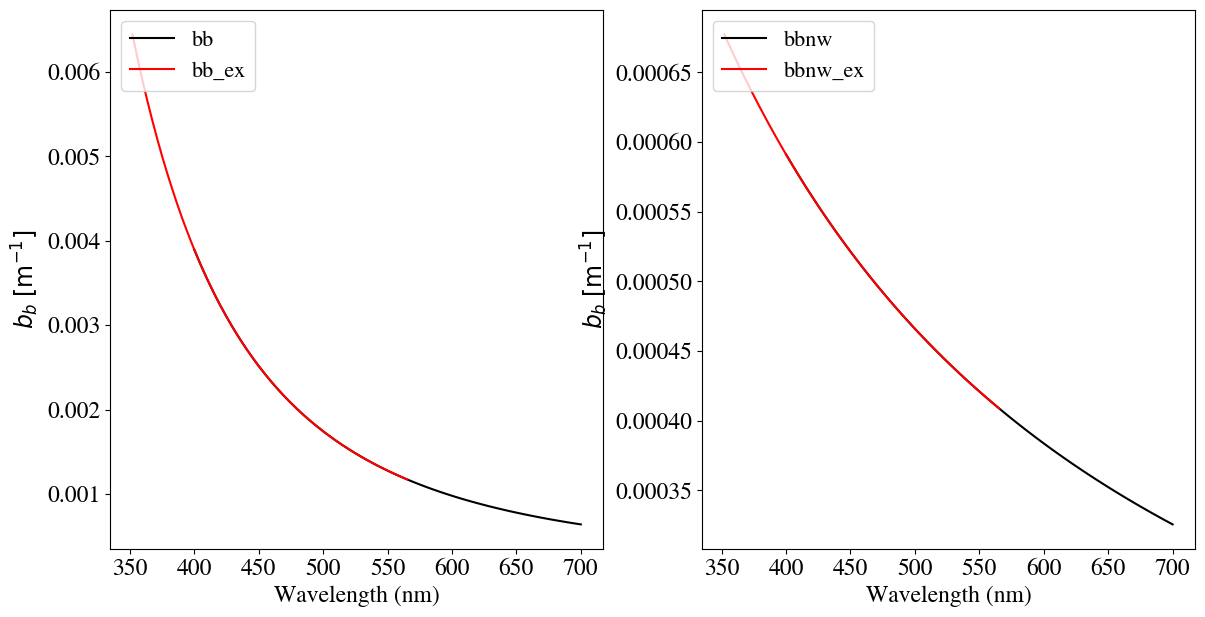

In [13]:
fig = plt.figure(figsize=(7,7))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
#
ax1.plot(models[1].wave, bb.flatten(), label='bb', color='black')
ax1.plot(models[1].wave_ex, bb_ex.flatten(), label='bb_ex', color='red')

ax2.plot(models[1].wave, bbnw.flatten(), label='bbnw', color='black')
ax2.plot(models[1].wave_ex, bbnw_ex.flatten(), label='bbnw_ex', color='red')
#
for ax in [ax1, ax2]:
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel(r'$b_b \; \rm [m^{-1}]$')
#ax.set_yscale('log')
#ax.set_ylim(1e-6, 1e-2)
    plotting.set_fontsize(ax, 17.)
    ax.legend(loc='upper left', fontsize=16.)
plt.show()

## Raman evaluation

In [14]:
reload(bing_eval)
rt_dict = {}
rt_dict['variable_Gordon'] = True 
G1, G2 = rrs.wave_dependent_gordon(models[0].wave)
models[0].G1 = G1
models[0].G2 = G2
rt_dict['include_Raman'] = True 

Rrs = bing_eval.calc_Rrs_from_models(models[0], stats['med'][:3], models[1], stats['med'][3:], rt_dict)

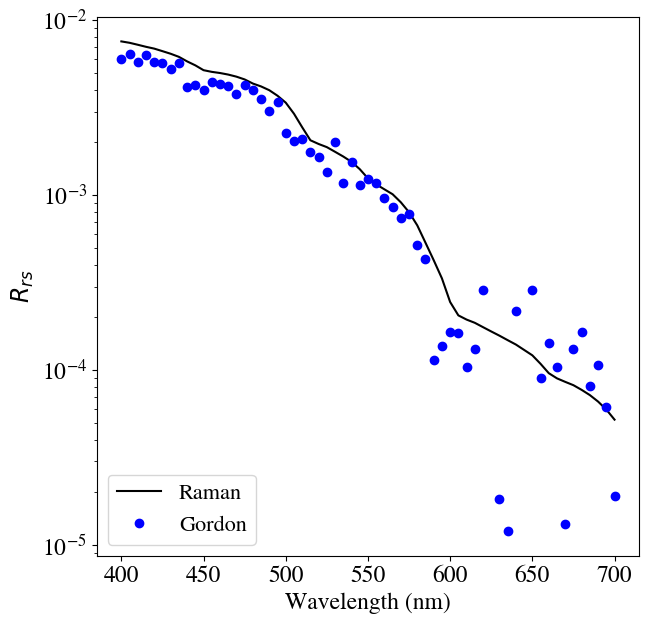

In [15]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
ax.plot(models[0].wave, Rrs.flatten(), label='Raman', color='black')
ax.plot(models[0].wave, prep_dict['model_Rrs'], 'o', label='Gordon', color='blue')
#
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{rs}$')
ax.set_yscale('log')
#ax.set_ylim(1e-6, 1e-2)
plotting.set_fontsize(ax, 17.)
ax.legend(loc='lower left', fontsize=16.)
plt.show()